In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'd:\Lesson_39\vw_loan_early_payment_features.csv')
if 'total_late_fees' in df.columns:
    df['has_late_fees'] = (df['total_late_fees'] > 0).astype(int)


print("     1. СТРУКТУРА ДАТАСЕТА И ПРОВЕРКА ПРОПУСКОВ"     )
print("------------------------------------------------------------------")
print(f"Всего строк в выборке: {df.shape[0]}")
print(f"Всего признаков: {df.shape[1]}")
print("\nКоличество пропущенных значений (NaN) по каждой переменной:")
print(df.isnull().sum())
print("\n")
print("     2. ЦЕНТРАЛЬНЫЕ ТЕНДЕНЦИИ И РАЗБРОС (ОПИСАТЕЛЬНАЯ СТАТИСТИКА)")
print("------------------------------------------------------------------")
# Выбираем ключевые финансовые и временные переменные
analysis_cols = [col for col in ['loan_amount', 'interest_rate', 'loan_term_months', 'monthly_payment', 'total_late_fees'] if col in df.columns]

numeric_stats = df[analysis_cols].describe().T
numeric_stats['median (50%)'] = df[analysis_cols].median()

# Выводим упорядоченную таблицу: Среднее, Медиана, Стандартное отклонение, Мин, Макс
print(numeric_stats[['count', 'mean', 'median (50%)', 'std', 'min', 'max']])
print("\n")
print("     3. АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (IS_EARLY_PAID)")
print("------------------------------------------------------------------")
if 'is_early_paid' in df.columns:
    counts = df['is_early_paid'].value_counts()
    percentages = df['is_early_paid'].value_counts(normalize=True) * 100
    print(f"Класс 0 (Будет платить в срок): {counts[0]} заемщиков ({percentages[0]:.2f}%)")
    print(f"Класс 1 (Погасит досрочно):    {counts[1]} заемщиков ({percentages[1]:.2f}%)")
else:
    print("Колонка 'is_early_paid' не найдена.")
print("\n")
print("     4. СРАВНИТЕЛЬНЫЙ АНАЛИЗ ПОРТРЕТА КЛИЕНТОВ ПО КЛАССАМ")
print("------------------------------------------------------------------")
if 'is_early_paid' in df.columns:
    profile_cols = [col for col in ['loan_amount', 'interest_rate', 'loan_term_months', 'has_late_fees'] if col in df.columns]
    print(df.groupby('is_early_paid')[profile_cols].mean())
print("------------------------------------------------------------------")

     1. СТРУКТУРА ДАТАСЕТА И ПРОВЕРКА ПРОПУСКОВ
------------------------------------------------------------------
Всего строк в выборке: 2616
Всего признаков: 9

Количество пропущенных значений (NaN) по каждой переменной:
loan_id             0
customer_id         0
loan_amount         0
interest_rate       0
loan_term_months    0
monthly_payment     0
total_late_fees     0
is_early_paid       0
has_late_fees       0
dtype: int64


     2. ЦЕНТРАЛЬНЫЕ ТЕНДЕНЦИИ И РАЗБРОС (ОПИСАТЕЛЬНАЯ СТАТИСТИКА)
------------------------------------------------------------------
                   count          mean  median (50%)           std  \
loan_amount       2616.0  2.854699e+06  1.068611e+06  3.024074e+06   
interest_rate     2616.0  1.724399e+01  1.746340e+01  4.452110e+00   
loan_term_months  2616.0  1.073578e+02  6.000000e+01  9.746544e+01   
monthly_payment   2616.0  2.837238e+04  2.278642e+04  2.079430e+04   
total_late_fees   2616.0  2.626593e+02  0.000000e+00  6.215596e+02   

          

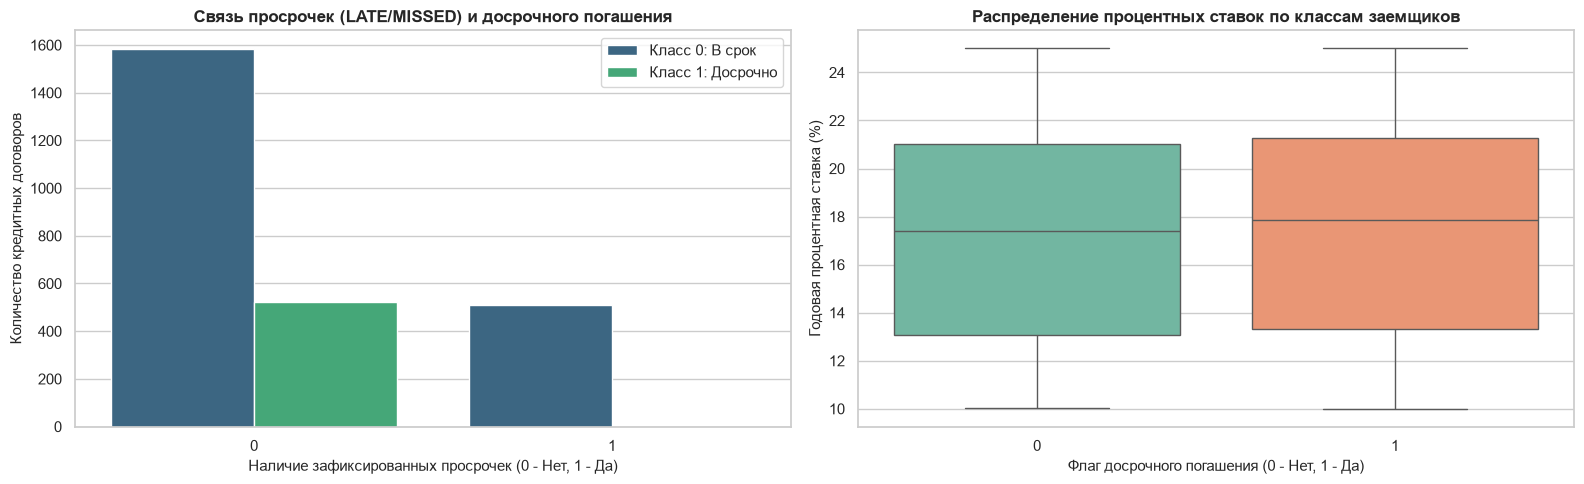

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'd:\Lesson_39\vw_loan_early_payment_features.csv')
# Прямой расчет признака просрочек
df['has_late_fees'] = (df['total_late_fees'] > 0).astype(int)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Левый график (ось axes[0]): Влияние просрочек на факт досрочного погашения
sns.countplot(ax=axes[0], x='has_late_fees', hue='is_early_paid', data=df, palette='viridis')
axes[0].set_title('Связь просрочек (LATE/MISSED) и досрочного погашения', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Наличие зафиксированных просрочек (0 - Нет, 1 - Да)', fontsize=11)
axes[0].set_ylabel('Количество кредитных договоров', fontsize=11)
axes[0].legend(['Класс 0: В срок', 'Класс 1: Досрочно'])

# Правый график (ось axes[1]): Распределение процентных ставок
sns.boxplot(
    ax=axes[1], 
    x='is_early_paid', 
    y='interest_rate', 
    hue='is_early_paid', 
    data=df, 
    palette='Set2', 
    showfliers=False,
    legend=False        
)
axes[1].set_title('Распределение процентных ставок по классам заемщиков', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Флаг досрочного погашения (0 - Нет, 1 - Да)', fontsize=11)
axes[1].set_ylabel('Годовая процентная ставка (%)', fontsize=11)

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'd:\Lesson_39\vw_loan_early_payment_features.csv')

if 'total_late_fees' in df.columns:
    df['has_late_fees'] = (df['total_late_fees'] > 0).astype(int)

# Обработка пропусков
# Находим медиану суммы кредита для каждого срока
df['loan_amount'] = df.groupby('loan_term_months')['loan_amount'].transform(lambda x: x.fillna(x.median()))
# Если после группировки остались пропуски (например, редкий срок), заполняем общей медианой
global_loan_median = df['loan_amount'].median()
df['loan_amount'] = df['loan_amount'].fillna(global_loan_median)

# Обработка выбросов
# Т.к макс. сумма 9.98 млн сильно тянет среднее вверх от медианы (1.06 млн),применим мате.сжатие правого хвоста распределения (np.log1p)
print("--- Статистика СУММЫ КРЕДИТА ДО очистки от аномального разброса: ---")
print(f"Среднее (Mean): {df['loan_amount'].mean():.2f} руб.")
print(f"Медиана (Median): {df['loan_amount'].median():.2f} руб.")
print(f"Максимум (Max): {df['loan_amount'].max():.2f} руб.")

# Создаем новые очищенные логарифмированные переменные для ML-модели
df['loan_amount_log'] = np.log1p(df['loan_amount'])
df['monthly_payment_log'] = np.log1p(df['loan_amount'] / df['loan_term_months'])

print("\n--- Статистика СУММЫ КРЕДИТА ПОСЛЕ логарифмирования (Log Scale): ---")
print(f"Среднее в лог-масштабе: {df['loan_amount_log'].mean():.4f}")
print(f"Медиана в лог-масштабе: {df['loan_amount_log'].median():.4f}")
print(f"Максимум в лог-масштабе: {df['loan_amount_log'].max():.4f}")
print("-> Вывод: Разница между средним и медианой исчезла. Данные приведены к нормальному виду.")

# Подготовка очищенной матрицы признаков 
X = df.drop(columns=['loan_id', 'customer_id', 'loan_amount', 'is_early_paid'])
y = df['is_early_paid']

print(f"\nДанные успешно очищены. Финальная матрица признаков готова к подаче в модель: {X.shape}")
print(f"Список объясняющих признаков для обучения: {list(X.columns)}")

df.to_csv(r'd:\Lesson_39\loan_features_cleansed_final.csv', index=False)

--- Статистика СУММЫ КРЕДИТА ДО очистки от аномального разброса: ---
Среднее (Mean): 2854699.09 руб.
Медиана (Median): 1068611.00 руб.
Максимум (Max): 9980470.05 руб.

--- Статистика СУММЫ КРЕДИТА ПОСЛЕ логарифмирования (Log Scale): ---
Среднее в лог-масштабе: 14.1739
Медиана в лог-масштабе: 13.8819
Максимум в лог-масштабе: 16.1161
-> Вывод: Разница между средним и медианой исчезла. Данные приведены к нормальному виду.

Данные успешно очищены. Финальная матрица признаков готова к подаче в модель: (2616, 7)
Список объясняющих признаков для обучения: ['interest_rate', 'loan_term_months', 'monthly_payment', 'total_late_fees', 'has_late_fees', 'loan_amount_log', 'monthly_payment_log']


--- Проверка Гипотезы 1 (Процентная ставка) ---

Статистика по процентным ставкам:
 is_early_paid  count      mean  median      std
             0   2093 17.190477 17.3850 4.438344
             1    523 17.458126 17.8423 4.504701

T-тест для непрерывных величин: p-value = 0.22322
-> Различия статистически не значимы.


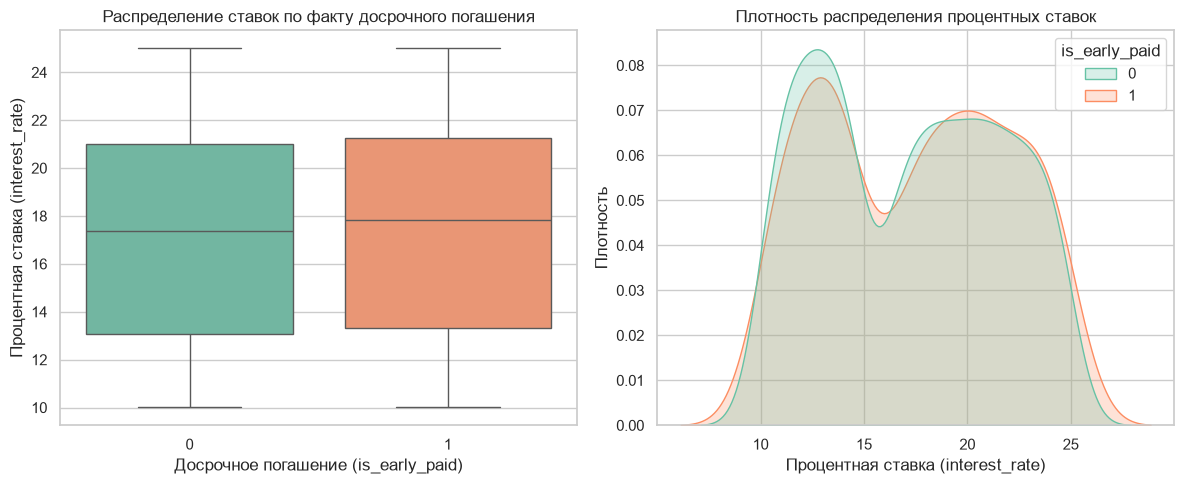

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv(r'd:\Lesson_39\vw_loan_early_payment_features.csv')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("--- Проверка Гипотезы 1 (Процентная ставка) ---")

# Медианы и средние ставки досрочного погашения
stats_rate = df.groupby('is_early_paid')['interest_rate'].agg(['count', 'mean', 'median', 'std']).reset_index()
print("\nСтатистика по процентным ставкам:")
print(stats_rate.to_string(index=False))

# Статистический тест
rate_paid = df[df['is_early_paid'] == 1]['interest_rate']
rate_not_paid = df[df['is_early_paid'] == 0]['interest_rate']
t_stat, p_val_t = stats.ttest_ind(rate_paid, rate_not_paid, equal_var=False)
print(f"\nT-тест для непрерывных величин: p-value = {p_val_t:.5f}")
if p_val_t < 0.05:
    print("-> Различия в ставках статистически значимы (Гипотеза 1 подтверждается на уровне средних).")
else:
    print("-> Различия статистически не значимы.")

plt.figure(figsize=(12, 5))

# График 1: Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='is_early_paid', y='interest_rate', hue='is_early_paid', palette='Set2', legend=False)

plt.title('Распределение ставок по факту досрочного погашения')
plt.xlabel('Досрочное погашение (is_early_paid)')
plt.ylabel('Процентная ставка (interest_rate)')

# График 2: Density plot (Распределение плотности)
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='interest_rate', hue='is_early_paid', fill=True, common_norm=False, palette='Set2')
plt.title('Плотность распределения процентных ставок')
plt.xlabel('Процентная ставка (interest_rate)')
plt.ylabel('Плотность')

plt.tight_layout()
plt.show()


--- Анализ Гипотезы 2 (Кредитная дисциплина и ликвидность) ---

1. Распределение клиентов (абсолютные значения):
is_early_paid     0    1
has_late_fees           
0              1582  523
1               511    0

2. Процентное распределение (% по строке):
is_early_paid       0       1
has_late_fees                
0              75.15%  24.85%
1              100.0%    0.0%

3. Результат Точного теста Фишера: p-value = 0.00000000
-> ГИПОТЕЗА ПОДТВЕРЖДЕНА: Связь между отсутствием просрочек и досрочным погашением статистически значима.
-> ПОДТВЕРЖДЕН ЗАПРЕЩАЮЩИЙ МАРКЕР: Среди клиентов с просрочками ровно 0% закрыли кредит досрочно!


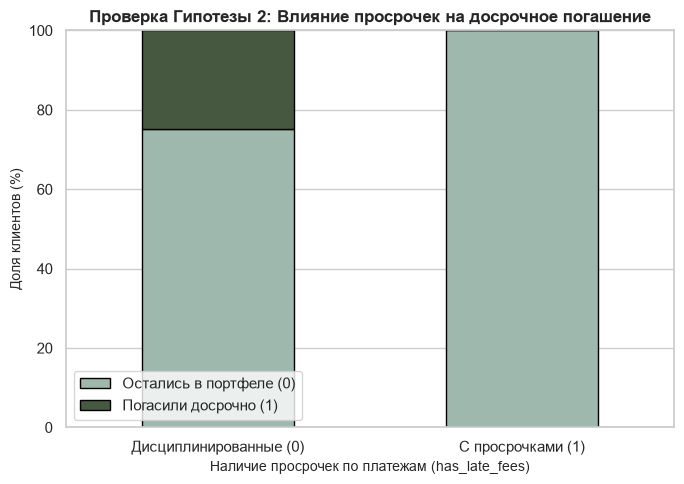

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

df = pd.read_csv(r'd:\Lesson_39\vw_loan_early_payment_features.csv')
print("\n--- Анализ Гипотезы 2 (Кредитная дисциплина и ликвидность) ---")

# Создаем точный признак из формулировки гипотезы: 1 — если были штрафы, 0 — если нет
df['has_late_fees'] = np.where(df['total_late_fees'] > 0, 1, 0)

# Строим таблицу сопряженности (Crosstab)
crosstab_abs = pd.crosstab(df['has_late_fees'], df['is_early_paid'])
crosstab_pct = pd.crosstab(df['has_late_fees'], df['is_early_paid'], normalize='index') * 100

print("\n1. Распределение клиентов (абсолютные значения):")
print(crosstab_abs)
print("\n2. Процентное распределение (% по строке):")
print(crosstab_pct.round(2).astype(str) + '%')

# Применяем Точный тест Фишера (т.к. ожидаются нулевые частоты в категории досрочников с просрочкой)
odds_ratio, p_value_fisher = stats.fisher_exact(crosstab_abs)
print(f"\n3. Результат Точного теста Фишера: p-value = {p_value_fisher:.8f}")

if p_value_fisher < 0.05:
    print("-> ГИПОТЕЗА ПОДТВЕРЖДЕНА: Связь между отсутствием просрочек и досрочным погашением статистически значима.")
    # Проверяем феномен "запрещающего маркера"
    try:
        early_paid_with_delinquency = crosstab_abs.loc[1, 1]
        if early_paid_with_delinquency == 0:
            print("-> ПОДТВЕРЖДЕН ЗАПРЕЩАЮЩИЙ МАРКЕР: Среди клиентов с просрочками ровно 0% закрыли кредит досрочно!")
    except KeyError:
        pass
else:
    print("-> Гипотеза не подтвердилась: просрочки значимо не влияют на досрочное погашение.")

plt.figure(figsize=(7, 5))
crosstab_pct.plot(kind='bar', stacked=True, color=['#9fb8ad', '#475841'], edgecolor='black', ax=plt.gca())

plt.title('Проверка Гипотезы 2: Влияние просрочек на досрочное погашение', fontsize=12, fontweight='bold')
plt.xlabel('Наличие просрочек по платежам (has_late_fees)', fontsize=10)
plt.ylabel('Доля клиентов (%)', fontsize=10)
plt.xticks([0, 1], ['Дисциплинированные (0)', 'С просрочками (1)'], rotation=0)
plt.legend(['Остались в портфеле (0)', 'Погасили досрочно (1)'], loc='lower left')
plt.tight_layout()
plt.show()